# Notebook to examine the MI risk and factors from a disclosive model
@Jim Smith 2023

## Initialise and get data

In [1]:
import pickle
import os
import logging
import json
import pandas as pd
import numpy as np

from scipy.io.arff import loadarff

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
directory = "MIA_analysis/"
print(f"Creating directory {directory} for training artefacts")

if not os.path.exists(directory):
    os.makedirs(directory)


path = os.path.join("user_stories/resources", "dataset_26_nursery.arff")
print("Reading data from " + path)
data = loadarff(path)
data = pd.DataFrame(data[0])
data = data.select_dtypes([object])
data = data.stack().str.decode("utf-8").unstack()

print("data read")

target_encoder = LabelEncoder()
target_vals = target_encoder.fit_transform(data["class"].values)
target_dataframe = pd.DataFrame({"class": target_vals})
data = data.drop(columns=["class"], inplace=False)

feature_encoder = OneHotEncoder()
x_encoded = feature_encoder.fit_transform(data).toarray()
feature_dataframe = pd.DataFrame(
    x_encoded, columns=feature_encoder.get_feature_names_out()
)

trainX, testX, trainy, testy = train_test_split(
    feature_dataframe.values,
    target_dataframe.values.flatten(),
    test_size=0.5,  # 7,
    random_state=42,
)

print("Saving training/testing data to ./" + directory)
np.savetxt(directory + "trainX.txt", trainX, fmt="%d")
np.savetxt(directory + "trainy.txt", trainy, fmt="%d")
np.savetxt(directory + "testX.txt", testX, fmt="%d")
np.savetxt(directory + "testy.txt", testy, fmt="%d")

Creating directory MIA_analysis/ for training artefacts
Reading data from user_stories/resources/dataset_26_nursery.arff
data read
Saving training/testing data to ./MIA_analysis/


## create disclosive model

In [3]:
# These hyperparameters lead to a dangerously disclosive trained model
DISCLOSIVE_HYPERPARAMETERS = {}
DISCLOSIVE_HYPERPARAMETERS["min_samples_split"] = 2
DISCLOSIVE_HYPERPARAMETERS["min_samples_leaf"] = 1
DISCLOSIVE_HYPERPARAMETERS["max_depth"] = None
DISCLOSIVE_HYPERPARAMETERS["bootstrap"] = False

print(
    "Training disclosive model with the following hyperparameters: "
    + str(DISCLOSIVE_HYPERPARAMETERS)
)
target_model = RandomForestClassifier(**DISCLOSIVE_HYPERPARAMETERS)
target_model.fit(trainX, trainy)

train_acc = accuracy_score(trainy, target_model.predict(trainX))
test_acc = accuracy_score(testy, target_model.predict(testX))
print(f"Training accuracy on disclosive model: {train_acc:.2f}")
print(f"Testing accuracy on disclosive model: {test_acc:.2f}")

filename = directory + "/disclosive_random_forest.sav"
print("Saving disclosive model to " + filename)
pickle.dump(target_model, open(filename, "wb"))

Training disclosive model with the following hyperparameters: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': False}
Training accuracy on disclosive model: 1.00
Testing accuracy on disclosive model: 0.98
Saving disclosive model to MIA_analysis//disclosive_random_forest.sav


In [4]:
print(target_model.get_params())

{'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


 ## now report the proba values for train and test set

In [5]:
trainx_proba = target_model.predict_proba(trainX)
testx_proba = target_model.predict_proba(testX)
numcols = trainx_proba.shape[1]

In [8]:
print("Training set probability descriptions")
print(pd.DataFrame(trainx_proba).describe())

# print(np.unique(trainx_proba,axis=0,return_counts=True))


print("Test set probability descriptions")
print(pd.DataFrame(testx_proba).describe())

print("Simple descriptive statistics: mean(sdev)")
for col in range(numcols):
    print(
        f"class {col} "
        f"train {np.mean(trainx_proba[:,col]):.3f} ({np.std(trainx_proba[:,col]):.3f}) "
        f"test {np.mean(testx_proba[:,col]):.3f} ({np.std(testx_proba[:,col]):.3f}) "
    )
# print(np.unique(testx_proba,axis=0,return_counts=True))

Training set probability descriptions
                 0            1            2            3
count  6480.000000  6480.000000  6480.000000  6480.000000
mean      0.330247     0.329321     0.316667     0.023765
std       0.470338     0.470003     0.465212     0.152329
min       0.000000     0.000000     0.000000     0.000000
25%       0.000000     0.000000     0.000000     0.000000
50%       0.000000     0.000000     0.000000     0.000000
75%       1.000000     1.000000     1.000000     0.000000
max       1.000000     1.000000     1.000000     1.000000
Test set probability descriptions
                 0            1            2            3
count  6480.000000  6480.000000  6480.000000  6480.000000
mean      0.336264     0.329687     0.308290     0.025759
std       0.468262     0.415546     0.418732     0.119269
min       0.000000     0.000000     0.000000     0.000000
25%       0.000000     0.000000     0.000000     0.000000
50%       0.010000     0.040000     0.020000     0.000000


## So a naive analysis might suggest that the train/test items have similar values for probabilities
### But that is not actually true as shown by plotting the CDFs and confirming via  by Kolmogor-Smirnov test

### CDFs for each class

In [9]:
import matplotlib.pyplot as plt

Text(0.5, 0.98, 'Plots of class probability(x) vs cumulative counts of records\nfor each class, split by train/test')

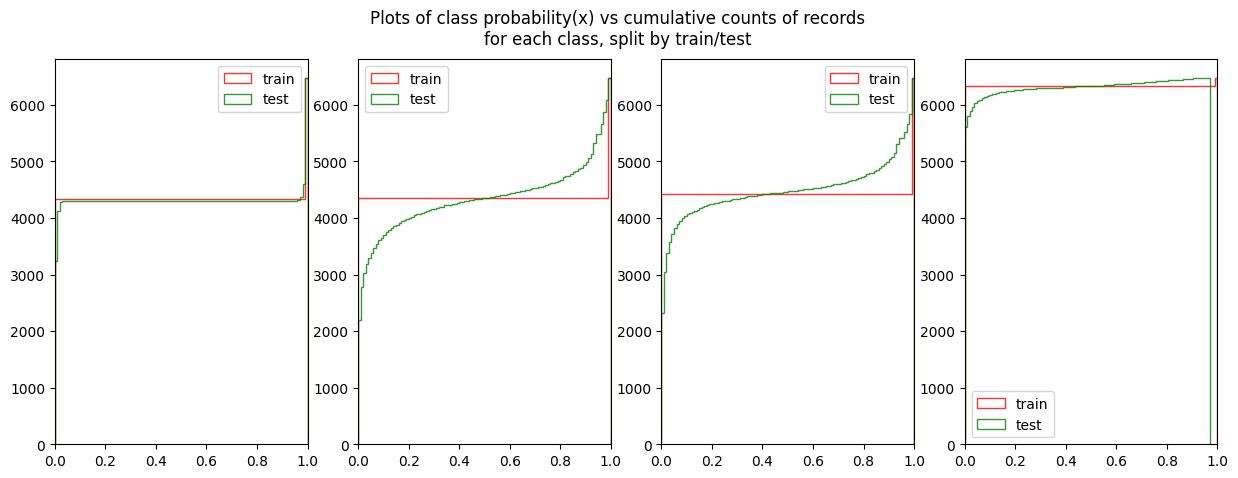

In [10]:
fig, axs = plt.subplots(1, numcols, figsize=(15, 5))

for col in range(numcols):
    axs[col].hist(
        trainx_proba[:, col],
        bins=100,
        cumulative=True,
        label="train",
        histtype="step",
        alpha=0.8,
        color="r",
    )
    axs[col].hist(
        testx_proba[:, col],
        bins=100,
        cumulative=True,
        label="test",
        histtype="step",
        alpha=0.8,
        color="g",
    )
    axs[col].set_xlim((0.0, 1.0))
    axs[col].legend()
fig.suptitle(
    "Plots of class probability(x) vs cumulative counts of records\nfor each class, split by train/test"
)

In [12]:
from scipy.stats import kstest

print("comparison of distributions of values using Kolmogorov-Smirnov test")
summ = []
for col in range(numcols):
    res = kstest(trainx_proba[:, col], testx_proba[:, col])
    summ.append(res)
    print(f" class{col}, outcome {res.statistic} probability {res.pvalue}")

comparison of distributions of values using Kolmogorov-Smirnov test
 class0, outcome 0.17006172839506173 probability 3.3128881956151423e-82
 class1, outcome 0.33240740740740743 probability 2.3630636e-317
 class2, outcome 0.324537037037037 probability 3.041057367101847e-302
 class3, outcome 0.11095679012345679 probability 3.847328354576342e-35


# Examining the k-anonymity shows why the model might be disclosive

(code taken from SafeRandomForestClassifier)

Even though there  are only four different  probability values forthe train set (the four variants of  3 0s and a 1),
these are not in a continuous area of decision space.

In [13]:
import copy


def get_k_anonymity(model: RandomForestClassifier, x: np.ndarray) -> np.array:
    """calculates the k-anonymity of a random forest model
    as the minimum of the anonymity for each record.
    That is defined as the size of the set of records which
    appear in the same leaf as the record in every tree.
    """

    # dataset must be 2-D
    assert len(x.shape) == 2

    num_records = x.shape[0]
    num_trees = model.n_estimators
    k_anon_val = np.zeros(num_records, dtype=int)

    # ending leaf node by record(row) and tree (column)
    all_leaves = np.zeros((num_records, num_trees), dtype=int)
    for this_tree in range(num_trees):
        this_leaves = model.estimators_[this_tree].apply(x)
        for record in range(num_records):
            all_leaves[record][this_tree] = this_leaves[record]

    for record in range(num_records):
        # start by assuming everything co-occurs
        appears_together = list(range(0, num_records))
        # iterate through trees
        for this_tree in range(num_trees):
            this_leaf = all_leaves[record][this_tree]

            together = copy.copy(appears_together)
            # removing records which go to other leaves
            for other_record in together:
                if all_leaves[other_record][this_tree] != this_leaf:
                    appears_together.remove(other_record)

        k_anon_val[record] = len(appears_together)
    return k_anon_val

In [14]:
train_k_anon = get_k_anonymity(target_model, trainX)

In [15]:
kvals = np.unique(train_k_anon, return_counts=True)
kvals_df = pd.DataFrame({"k-anonymity": kvals[0], "number of cases": kvals[1]})
kvals_df

,k-anonymity,number of cases
0,1,6480


## confirm by taking a single 2-D slice of the decision surface
and plotting the models confidence that the class is 0 across that slice 